# Q3: Feature Engineering — Retail Promotions Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Load data
try:
    df3 = pd.read_csv('../data/q3_retail_promotions.csv')
except Exception:
    df3 = pd.read_csv('q3_retail_promotions.csv')
print('Loaded retail promotions dataset with shape:', df3.shape)

Loaded retail promotions dataset with shape: (1200, 9)


In [2]:
# Data Inspection
print('Columns:', df3.columns.tolist())
print()
print('Dtypes:')
print(df3.dtypes)
print()
print('Missing values:')
print(df3.isna().sum())
print()
print('Head:')
print(df3.head())

Columns: ['transaction_date', 'store_id', 'store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'items_sold']

Dtypes:
transaction_date       object
store_id                int64
store_size             object
location_type          object
promotion_type         object
is_weekend              int64
is_festival             int64
competition_density     int64
items_sold              int64
dtype: object

Missing values:
transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64

Head:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points

## Exploratory Data Analysis

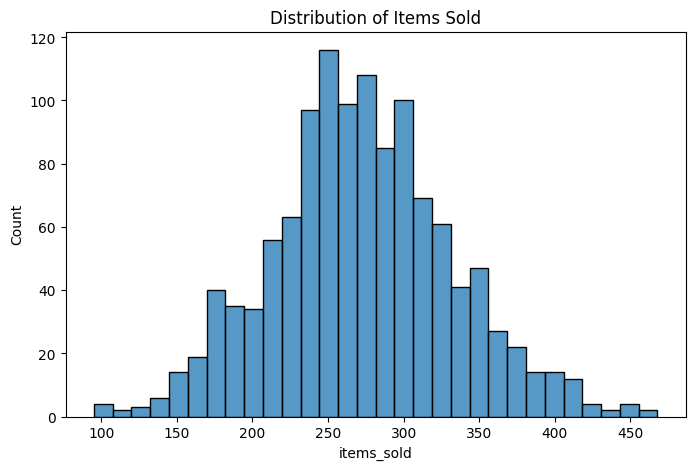

In [3]:
# Distribution of items sold
plt.figure(figsize=(8,5))
sns.histplot(df3['items_sold'], bins=30)
plt.title('Distribution of Items Sold')
plt.show()

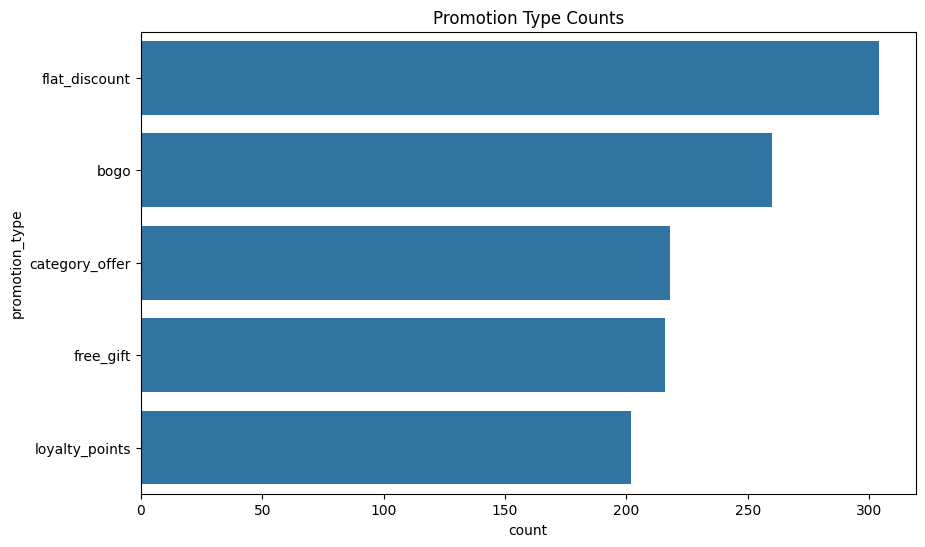

In [4]:
# Countplot of promotion types
plt.figure(figsize=(10,6))
sns.countplot(y='promotion_type', data=df3, order=df3['promotion_type'].value_counts().index)
plt.title('Promotion Type Counts')
plt.show()

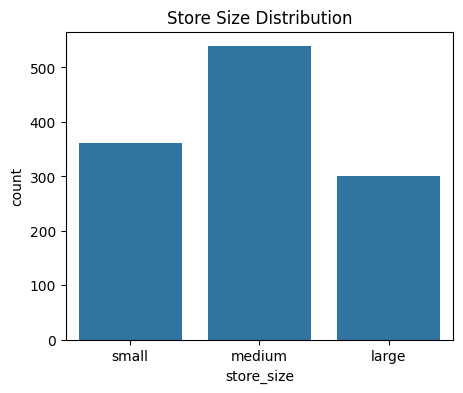

In [5]:
# Countplot of store size
plt.figure(figsize=(5,4))
sns.countplot(x='store_size', data=df3)
plt.title('Store Size Distribution')
plt.show()

## Feature Engineering

In [6]:
# Convert transaction_date to datetime and extract features
df3['transaction_date'] = pd.to_datetime(df3['transaction_date'])
df3['year'] = df3['transaction_date'].dt.year
df3['month'] = df3['transaction_date'].dt.month
# day of week name
df3['day_of_week'] = df3['transaction_date'].dt.day_name()
df3['week_of_year'] = df3['transaction_date'].dt.isocalendar().week
df3['day'] = df3['transaction_date'].dt.day
print(df3[['transaction_date','year','month','day_of_week','week_of_year','day']].head())

  transaction_date  year  month day_of_week  week_of_year  day
0       2022-01-01  2022      1    Saturday            52    1
1       2022-01-01  2022      1    Saturday            52    1
2       2022-01-02  2022      1      Sunday            52    2
3       2022-01-02  2022      1      Sunday            52    2
4       2022-01-03  2022      1      Monday             1    3


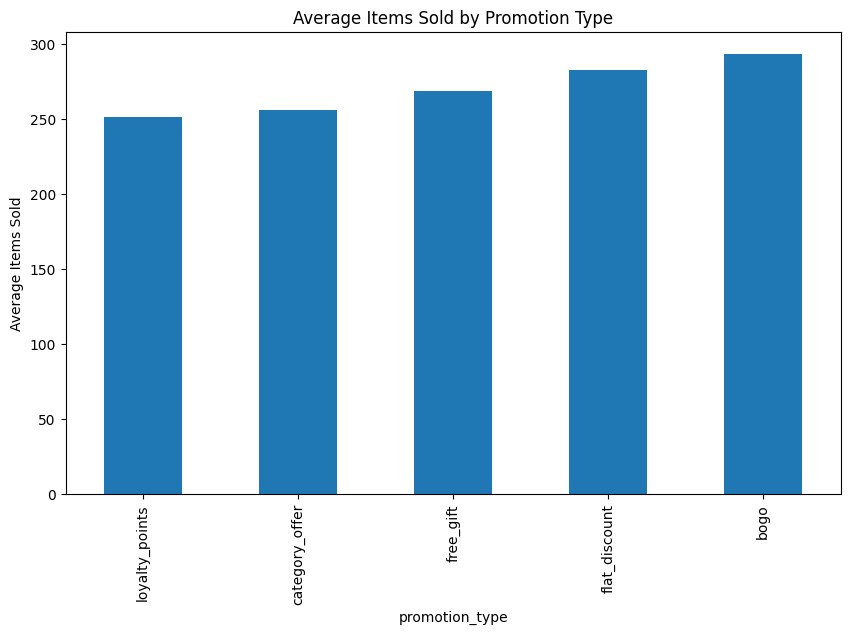

In [7]:
# Average items sold by promotion type
df3.groupby('promotion_type')['items_sold'].mean().sort_values().plot(kind='bar', figsize=(10,6))
plt.ylabel('Average Items Sold')
plt.title('Average Items Sold by Promotion Type')
plt.show()

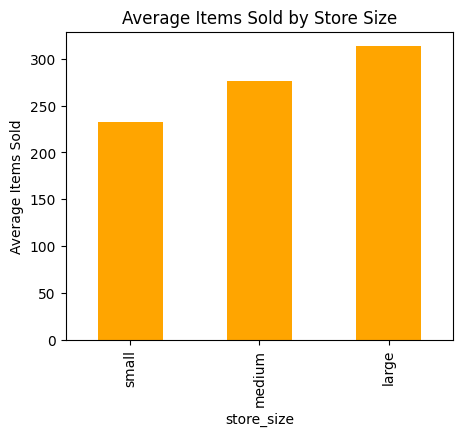

In [8]:
# Average items sold by store size
df3.groupby('store_size')['items_sold'].mean().sort_values().plot(kind='bar', color='orange', figsize=(5,4))
plt.ylabel('Average Items Sold')
plt.title('Average Items Sold by Store Size')
plt.show()

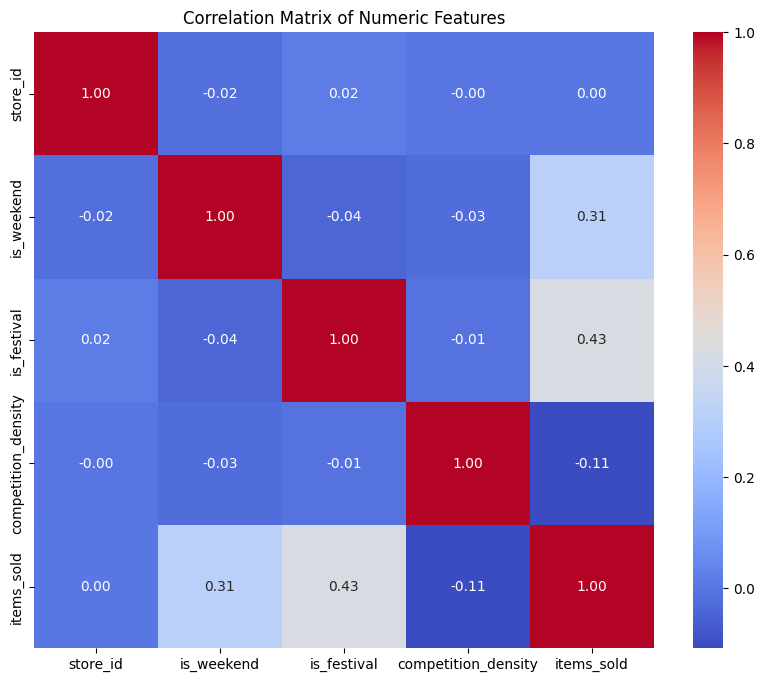

In [9]:
# Correlation matrix for numeric features
numeric_cols = df3.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(10,8))
sns.heatmap(df3[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

## Modeling with Engineered Features (Regression)

In [10]:
# Define X and y
X = df3.drop(['items_sold','transaction_date'], axis=1)
y = df3['items_sold']
# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print('Categorical columns:', cat_cols)
print('Numeric columns:', numeric_cols)
# Build pipeline: one-hot encode categoricals, scale numerics
preproc = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
# Use random forest regressor
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg_pipe = Pipeline([('preproc', preproc), ('model', reg)])
# Train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg_pipe.fit(X_train, y_train)
y_pred = reg_pipe.predict(X_test)
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 Score:', r2_score(y_test, y_pred))

Categorical columns: ['store_size', 'location_type', 'promotion_type', 'day_of_week']
Numeric columns: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'week_of_year', 'day']


RMSE: 30.330063262380445
R2 Score: 0.7592546643926481


The above demonstrates feature engineering: date components extracted and variables encoded for use in models. A simple random forest regressor suggests how engineered features can predict items sold (though objective and model choice may vary depending on business goals).